In [35]:
# ==============================================================================
# LANGKAH 1: SETUP LINGKUNGAN
# ==============================================================================
# Menginstal library yang diperlukan.
# - timm: Pustaka model PyTorch yang berisi banyak model state-of-the-art, termasuk Vision Transformer.
# - scikit-learn: Digunakan untuk menghitung metrik evaluasi seperti F1-score.
!pip install -q timm scikit-learn

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from PIL import Image
from sklearn.metrics import f1_score, accuracy_score
import timm
from tqdm.auto import tqdm # Untuk progress bar yang lebih baik

print(f"PyTorch Version: {torch.__version__}")
print(f"Timm Version: {timm.__version__}")

# ==============================================================================
# LANGKAH 2: PERSIAPAN DATA
# ==============================================================================

# --- Tentukan path ke direktori data Anda ---
DATA_DIR = '/kaggle/input/srifoton/srifoton-25-machine-learning-competition/'
TRAIN_DIR = os.path.join(DATA_DIR, 'train/train')
VAL_DIR = os.path.join(DATA_DIR, 'val/val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# --- Definisikan Transformasi Gambar ---
# Model ViT yang akan kita gunakan di-pretrain pada gambar ukuran 224x224.
IMG_SIZE = 224
# Nilai mean dan std ini adalah standar untuk model yang di-pretrain di ImageNet.
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

# Transformasi untuk data training:
# - RandomResizedCrop: Memotong gambar secara acak ke ukuran 224x224. Ini adalah bentuk augmentasi.
# - RandomHorizontalFlip: Membalik gambar secara horizontal dengan probabilitas 50%.
# - ToTensor: Mengubah gambar menjadi PyTorch Tensor.
# - Normalize: Menormalisasi tensor gambar.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

# Transformasi untuk data validasi dan test (tanpa augmentasi):
# - Resize: Mengubah ukuran sisi terpendek gambar menjadi 256.
# - CenterCrop: Memotong bagian tengah gambar menjadi 224x224.
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])


# --- Buat Dataset menggunakan ImageFolder ---
# ImageFolder secara otomatis menemukan kelas dari nama subfolder.
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_test_transform)

# --- Buat Custom Dataset untuk data Test ---
# Folder test tidak memiliki subfolder kelas, jadi kita perlu class custom.
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if os.path.isfile(os.path.join(root_dir, f))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx] # Mengembalikan gambar dan nama filenya

test_dataset = TestDataset(TEST_DIR, transform=val_test_transform)


# --- Buat DataLoaders ---
# DataLoader mengatur data ke dalam batch-batch untuk training dan evaluasi.
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Menampilkan informasi kelas yang ditemukan
class_names = train_dataset.classes
print("Kelas yang ditemukan:", class_names)
# Output: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']
# Ini akan otomatis di-map ke label 0, 1, 2, 3, 4

# ==============================================================================
# LANGKAH 3: INISIALISASI MODEL ViT
# ==============================================================================

# Cek ketersediaan GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Menggunakan device: {device}")

# Muat model ViT pre-trained dari timm
# 'vit_base_patch16_224' adalah model ViT standar yang populer.
# pretrained=True berarti kita menggunakan bobot yang sudah dilatih di ImageNet.
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=len(class_names))
print(f"Model ViT '{type(model).__name__}' berhasil dimuat.")

# ==============================================================================
# LANGKAH 4: KONFIGURASI PROSES TRAINING
# ==============================================================================

# Pindahkan model ke device (GPU)
model.to(device)

# Tentukan Loss Function
# CrossEntropyLoss cocok untuk masalah klasifikasi multi-kelas.
criterion = nn.CrossEntropyLoss()

# Tentukan Optimizer
# AdamW adalah optimizer yang direkomendasikan untuk model berbasis Transformer.
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Tentukan Learning Rate Scheduler (Opsional, tapi direkomendasikan)
# Mengurangi learning rate setelah beberapa epoch untuk membantu model konvergen.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# ==============================================================================
# LANGKAH 5: LOOP TRAINING DAN VALIDASI
# ==============================================================================

NUM_EPOCHS = 10
best_f1_score = 0.0
MODEL_SAVE_PATH = 'best_model.pth'

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    progress_bar = tqdm(train_loader, desc="Training")
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        # Nol-kan gradien
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass dan optimisasi
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        progress_bar.set_postfix(loss=loss.item())

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc="Validating")
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

            # Dapatkan prediksi
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --- Hitung Metrik ---
    epoch_train_loss = train_loss / len(train_dataset)
    epoch_val_loss = val_loss / len(val_dataset)
    # Gunakan average='macro' sesuai ketentuan kompetisi
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_accuracy = accuracy_score(all_labels, all_preds)

    print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_accuracy:.4f} | Val Macro F1: {val_f1:.4f}")

    # Simpan model jika Macro F1-Score membaik
    if val_f1 > best_f1_score:
        best_f1_score = val_f1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"✨ Model terbaik disimpan! Macro F1: {best_f1_score:.4f}")

    # Update learning rate
    scheduler.step()


print("\nTraining selesai!")
print(f"Macro F1 Score terbaik di validasi: {best_f1_score:.4f}")

# ==============================================================================
# LANGKAH 6: INFERENSI DAN PEMBUATAN FILE SUBMISSION
# ==============================================================================

print("\nMemulai proses inferensi pada data test...")

# Buat model baru dan muat bobot terbaik
submission_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=len(class_names))
submission_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
submission_model.to(device)
submission_model.eval()

# Lakukan prediksi
test_predictions = []
test_image_ids = []
with torch.no_grad():
    for inputs, filenames in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = submission_model(inputs)
        _, preds = torch.max(outputs, 1)

        test_predictions.extend(preds.cpu().numpy())
        test_image_ids.extend(filenames)

# Buat DataFrame untuk submission
submission_df = pd.DataFrame({
    'Id': test_image_ids,
    'Predicted': test_predictions
})

# Pastikan urutan kelas sesuai (0 untuk Bacterial, 1 untuk Corona, dst.)
# Karena ImageFolder mengurutkan kelas secara alfabetis, mapping-nya sudah benar.
# Jika tidak, kita perlu mapping manual di sini.

# Simpan ke file CSV
submission_df.to_csv('submission.csv', index=False)

print("\nFile submission.csv berhasil dibuat!")
print("Contoh isi file submission:")
print(submission_df.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00:00:010:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.2 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 3.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 50.1 MB/s eta 0:00:0000:0100:01
PyTorch Version: 2.6.0+cu124
Timm Version: 1.0.15
Kelas yang ditemukan: ['Bacterial Pneumonia', 'Corona V

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model ViT 'VisionTransformer' berhasil dimuat.

--- Epoch 1/10 ---


Training:   0%|          | 0/190 [00:00<?, ?it/s]

Validating:   0%|          | 0/63 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/63 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f7cd00c3880>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f7cd00c3880>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 16

Train Loss: 0.2362 | Val Loss: 0.2613 | Val Acc: 0.9018 | Val Macro F1: 0.8996
✨ Model terbaik disimpan! Macro F1: 0.8996

Training selesai!
Macro F1 Score terbaik di validasi: 0.8996

Memulai proses inferensi pada data test...


Testing: 0it [00:00, ?it/s]


File submission.csv berhasil dibuat!
Contoh isi file submission:
Empty DataFrame
Columns: [Id, Predicted]
Index: []


Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 239, in _feed
    reader_close()
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 271, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times


Memuat model terbaik untuk evaluasi...


Mengevaluasi Model Terbaik:   0%|          | 0/63 [00:00<?, ?it/s]


             Laporan Klasifikasi (Validation Set)
                      precision    recall  f1-score   support

 Bacterial Pneumonia       0.80      0.84      0.82       401
Corona Virus Disease       0.98      1.00      0.99       406
              Normal       0.92      0.97      0.94       402
        Tuberculosis       1.00      0.99      0.99       406
     Viral Pneumonia       0.80      0.71      0.75       401

            accuracy                           0.90      2016
           macro avg       0.90      0.90      0.90      2016
        weighted avg       0.90      0.90      0.90      2016


             Membuat Visualisasi Confusion Matrix


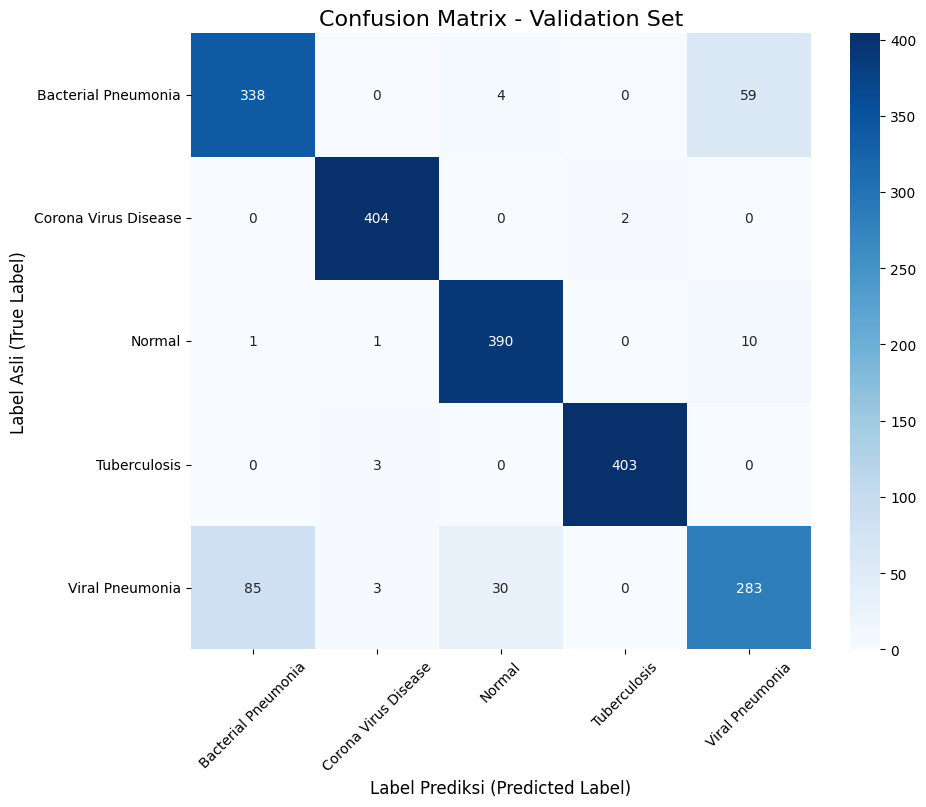

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# EVALUASI MODEL TERBAIK PADA SET VALIDASI
# ==============================================================================

print("Memuat model terbaik untuk evaluasi...")
# Pastikan arsitektur model sama persis dengan yang digunakan saat training
eval_model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=len(class_names))

# Muat bobot (state dictionary) dari file yang disimpan
eval_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
eval_model.to(device)
eval_model.eval() # Set model ke mode evaluasi

# --- Kumpulkan Prediksi dan Label Asli dari Validation Set ---
y_true = []
y_pred = []

with torch.no_grad(): # Tidak perlu menghitung gradien saat evaluasi
    for inputs, labels in tqdm(val_loader, desc="Mengevaluasi Model Terbaik"):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Dapatkan output dari model
        outputs = eval_model(inputs)
        # Dapatkan prediksi kelas dengan nilai tertinggi
        _, predicted = torch.max(outputs, 1)

        # Kumpulkan hasil prediksi dan label asli
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# ==============================================================================
# LANGKAH 1: TAMPILKAN CLASSIFICATION REPORT
# ==============================================================================

print("\n" + "="*50)
print("             Laporan Klasifikasi (Validation Set)")
print("="*50)

# Menghasilkan laporan yang berisi precision, recall, f1-score, dan support untuk setiap kelas
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


# ==============================================================================
# LANGKAH 2: VISUALISASI CONFUSION MATRIX
# ==============================================================================

print("\n" + "="*50)
print("             Membuat Visualisasi Confusion Matrix")
print("="*50)

# Menghasilkan confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Membuat plot heatmap menggunakan Seaborn untuk visualisasi yang lebih baik
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

# Menambahkan judul dan label
plt.title('Confusion Matrix - Validation Set', fontsize=16)
plt.ylabel('Label Asli (True Label)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted Label)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [39]:
import os
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import timm
from tqdm.auto import tqdm

# ==============================================================================
# 1. SETUP & KONFIGURASI
# ==============================================================================
# Pastikan variabel-variabel ini sesuai dengan setup Anda dari kode sebelumnya
DATA_DIR = '/kaggle/input/srifoton/srifoton-25-machine-learning-competition/'
TEST_DIR = os.path.join(DATA_DIR, 'test/test')
MODEL_SAVE_PATH = 'best_model.pth'
BATCH_SIZE = 32 # Bisa disesuaikan tergantung VRAM GPU

# Gunakan device yang sama dengan saat training
device = "cuda" if torch.cuda.is_available() else "cpu"

# Gunakan transformasi yang SAMA PERSIS dengan validation set (tanpa augmentasi)
# Ini penting untuk konsistensi
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Ambil nama kelas dari dataset training (jika belum ada)
# train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train/train'))
# class_names = train_dataset.classes
# print(f"Nama kelas: {class_names}")

# ==============================================================================
# 2. PERSIAPAN DATA TEST
# ==============================================================================
# Class Dataset custom untuk folder test yang tidak memiliki sub-folder kelas
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = sorted([f for f in os.listdir(root_dir) if f.endswith('.jpeg')])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        # Mengembalikan gambar dan nama filenya (ID)
        return image, self.image_files[idx]

# Buat instance Dataset dan DataLoader
test_dataset = TestDataset(TEST_DIR, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Ditemukan {len(test_dataset)} gambar di folder test.")

# ==============================================================================
# 3. MUAT MODEL TERBAIK
# ==============================================================================
# Inisialisasi arsitektur model yang sama
model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=len(class_names))

# Muat bobot terbaik yang telah disimpan
model.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Pindahkan model ke GPU dan set ke mode evaluasi
model.to(device)
model.eval()
print("Model terbaik berhasil dimuat dan disetel ke mode evaluasi.")

# ==============================================================================
# 4. LAKUKAN PREDIKSI (INFERENSI)
# ==============================================================================
test_predictions = []
test_image_ids = []

# `torch.no_grad()` mempercepat proses inferensi dan mengurangi penggunaan memori
with torch.no_grad():
    # Gunakan tqdm untuk melihat progress bar
    for inputs, filenames in tqdm(test_loader, desc="Memprediksi data test"):
        # Pindahkan data ke device (GPU)
        inputs = inputs.to(device)
        
        # Lakukan forward pass untuk mendapatkan output (logits)
        outputs = model(inputs)
        
        # Dapatkan kelas dengan probabilitas tertinggi
        _, preds = torch.max(outputs, 1)
        
        # Kumpulkan hasil prediksi dan ID gambar
        test_predictions.extend(preds.cpu().numpy())
        test_image_ids.extend(filenames)

# ==============================================================================
# 5. BUAT DAN SIMPAN FILE SUBMISSION
# ==============================================================================
print("\nMembuat file submission...")

# Buat DataFrame pandas sesuai format yang diminta
submission_df = pd.DataFrame({
    'Id': test_image_ids,
    'Predicted': test_predictions
})

# Simpan DataFrame ke file CSV
# `index=False` agar nomor indeks baris tidak ikut tersimpan
submission_df.to_csv('submission.csv', index=False)

print("✅ File 'submission.csv' berhasil dibuat!")
print("Berikut adalah 5 baris pertama dari file submission Anda:")
print(submission_df.head())

Ditemukan 2025 gambar di folder test.
Model terbaik berhasil dimuat dan disetel ke mode evaluasi.


Memprediksi data test:   0%|          | 0/64 [00:00<?, ?it/s]


Membuat file submission...
✅ File 'submission.csv' berhasil dibuat!
Berikut adalah 5 baris pertama dari file submission Anda:
               Id  Predicted
0  test_0001.jpeg          3
1  test_0002.jpeg          0
2  test_0003.jpeg          2
3  test_0004.jpeg          4
4  test_0005.jpeg          2


Rework Vision Transform

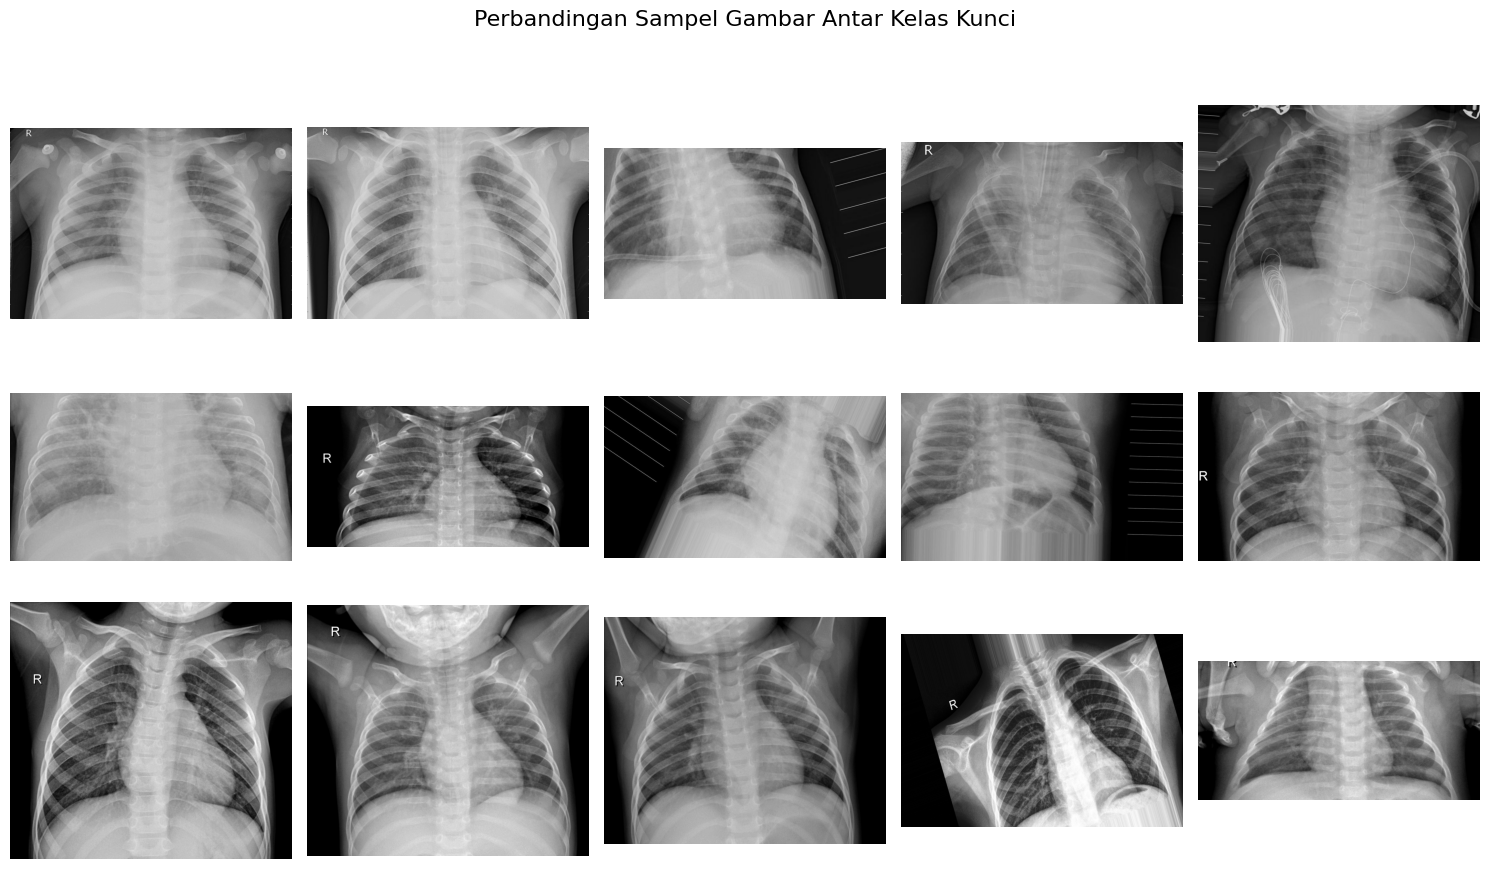

In [50]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2
import seaborn as sns

# --- Konfigurasi Path ---
BASE_DIR = '/kaggle/input/srifoton/srifoton-25-machine-learning-competition/'
TRAIN_DIR = os.path.join(BASE_DIR, 'train/train')
CLASSES_TO_VISUALIZE = ['Bacterial Pneumonia', 'Viral Pneumonia', 'Normal']
NUM_SAMPLES = 5 # Jumlah sampel per kelas

# --- Membuat Plot ---
fig, axes = plt.subplots(len(CLASSES_TO_VISUALIZE), NUM_SAMPLES, figsize=(15, 9))
fig.suptitle('Perbandingan Sampel Gambar Antar Kelas Kunci', fontsize=16)

for i, class_name in enumerate(CLASSES_TO_VISUALIZE):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    image_files = os.listdir(class_dir)
    random_samples = random.sample(image_files, NUM_SAMPLES)
    
    # Menampilkan nama kelas di awal setiap baris
    axes[i, 0].set_ylabel(class_name, fontsize=12, rotation=0, labelpad=80, ha='center', va='center')
    
    for j, image_file in enumerate(random_samples):
        img_path = os.path.join(class_dir, image_file)
        img = Image.open(img_path)
        
        ax = axes[i, j]
        ax.imshow(img, cmap='gray')
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Menganalisis Kecerahan:   0%|          | 0/5 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

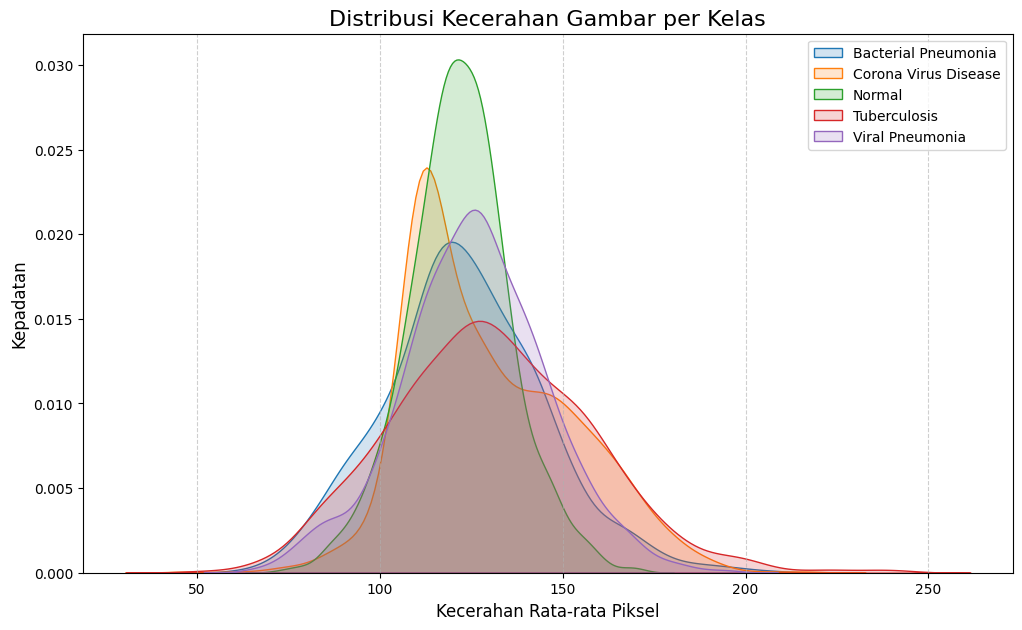

In [51]:
brightness_data = {}
all_classes = sorted(os.listdir(TRAIN_DIR))

# Loop melalui setiap kelas untuk mengumpulkan data kecerahan
for class_name in tqdm(all_classes, desc="Menganalisis Kecerahan"):
    if class_name.startswith('.'): continue # Skip file tersembunyi
    class_dir = os.path.join(TRAIN_DIR, class_name)
    brightness_values = []
    for image_file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, image_file)
        # Baca sebagai grayscale dan hitung rata-rata
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            brightness_values.append(img.mean())
    brightness_data[class_name] = brightness_values

# --- Membuat Plot Distribusi ---
plt.figure(figsize=(12, 7))
for class_name, values in brightness_data.items():
    sns.kdeplot(values, label=class_name, fill=True, alpha=0.2)

plt.title('Distribusi Kecerahan Gambar per Kelas', fontsize=16)
plt.xlabel('Kecerahan Rata-rata Piksel', fontsize=12)
plt.ylabel('Kepadatan', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Mencari Gambar Miring:   0%|          | 0/5 [00:00<?, ?it/s]


Ditemukan 39 gambar dengan rotasi signifikan.
Menampilkan 10 contoh paling miring:


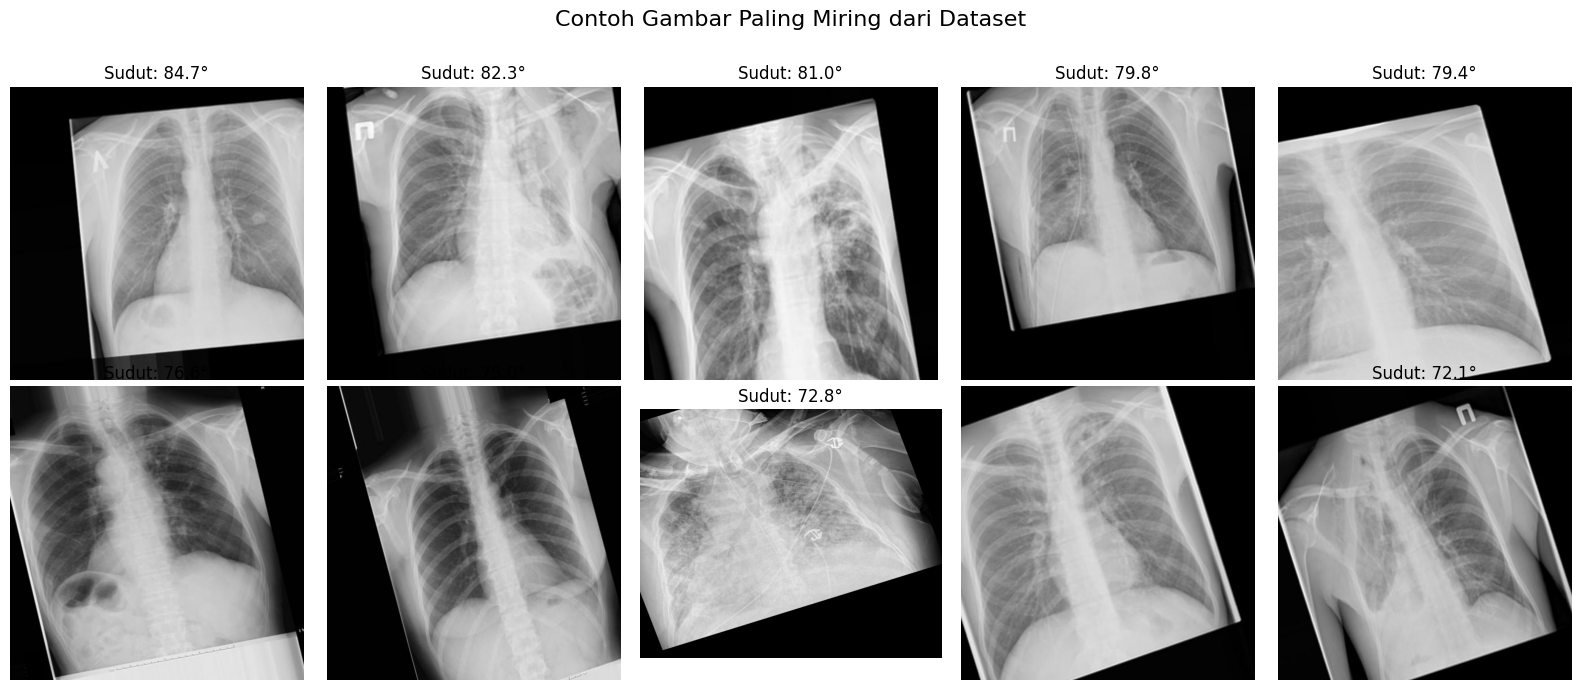

In [52]:
tilted_images = []

# Loop melalui seluruh dataset untuk menemukan gambar miring
# (Ini mungkin memakan waktu beberapa menit)
for class_name in tqdm(all_classes, desc="Mencari Gambar Miring"):
    if class_name.startswith('.'): continue
    class_dir = os.path.join(TRAIN_DIR, class_name)
    for image_file in os.listdir(class_dir):
        img_path = os.path.join(class_dir, image_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if img is not None:
            # Threshold untuk mendapatkan kontur tubuh/paru-paru
            _, thresh = cv2.threshold(img, 25, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                # Ambil kontur terbesar
                largest_contour = max(contours, key=cv2.contourArea)
                # Dapatkan sudut dari bounding box minimum
                rect = cv2.minAreaRect(largest_contour)
                angle = rect[-1]
                
                # Normalisasi sudut agar lebih mudah diinterpretasi
                if angle < -45:
                    angle = 90 + angle
                
                # Simpan gambar dengan rotasi signifikan (bukan yang hampir lurus)
                if abs(angle) > 5 and abs(angle) < 85:
                    tilted_images.append({'path': img_path, 'angle': angle})

# Urutkan gambar berdasarkan tingkat kemiringan
tilted_images.sort(key=lambda x: abs(x['angle']), reverse=True)

# --- Tampilkan 10 gambar paling miring ---
print(f"\nDitemukan {len(tilted_images)} gambar dengan rotasi signifikan.")
print("Menampilkan 10 contoh paling miring:")

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Contoh Gambar Paling Miring dari Dataset', fontsize=16)
axes = axes.flatten()

for i in range(min(10, len(tilted_images))):
    img_data = tilted_images[i]
    img = Image.open(img_data['path'])
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Sudut: {img_data['angle']:.1f}°")
    axes[i].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Tahap 2

In [54]:
import cv2
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import random
import os
import matplotlib.pyplot as plt

# Pastikan library yang dibutuhkan sudah terimpor
# from tqdm.auto import tqdm

class ApplyCLAHE:
    """
    Sebuah class transform torchvision untuk menerapkan CLAHE pada gambar.
    CLAHE diterapkan pada gambar grayscale, lalu dikonversi kembali ke 3 channel
    agar kompatibel dengan model pre-trained.
    """
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img):
        # Konversi PIL Image ke array NumPy
        img_np = np.array(img)
        
        # Konversi ke Grayscale
        gray_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        
        # Buat objek CLAHE dan terapkan
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        clahe_img = clahe.apply(gray_img)
        
        # Konversi kembali ke 3 channel dengan menumpuk channel grayscale
        img_clahe_3_channel = np.stack([clahe_img]*3, axis=-1)
        
        # Konversi kembali ke PIL Image
        return Image.fromarray(img_clahe_3_channel)

print("Custom transform 'ApplyCLAHE' berhasil dibuat.")

Custom transform 'ApplyCLAHE' berhasil dibuat.


In [55]:
# --- Konfigurasi Normalisasi ---
# Gunakan nilai yang sama seperti sebelumnya untuk konsistensi
IMG_SIZE = 224
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

# --- Pipeline Augmentasi Baru untuk Training ---
new_train_transform = transforms.Compose([
    # 1. Terapkan CLAHE untuk meningkatkan kontras lokal
    ApplyCLAHE(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    # 2. Augmentasi geometris yang kuat untuk mengatasi rotasi dan pergeseran
    transforms.RandomAffine(
        degrees=15,           # Rotasi acak hingga 15 derajat
        translate=(0.1, 0.1), # Geser gambar secara horizontal/vertikal hingga 10%
        scale=(0.9, 1.1),     # Zoom in/out acak dari 90% hingga 110%
        shear=10              # Pergeseran (shear) hingga 10 derajat
    ),
    
    # 3. Augmentasi warna untuk ketahanan terhadap variasi pencahayaan
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    
    # 4. Flip horizontal standar
    transforms.RandomHorizontalFlip(),

    # 5. Konversi ke Tensor dan Normalisasi (langkah wajib)
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

# --- Pipeline untuk Validasi (tetap sama, tanpa augmentasi acak) ---
# Namun, kita tambahkan CLAHE agar input validasi konsisten dengan training
val_transform_with_clahe = transforms.Compose([
    ApplyCLAHE(),
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])


print("Pipeline augmentasi baru 'new_train_transform' berhasil dibuat.")

Pipeline augmentasi baru 'new_train_transform' berhasil dibuat.


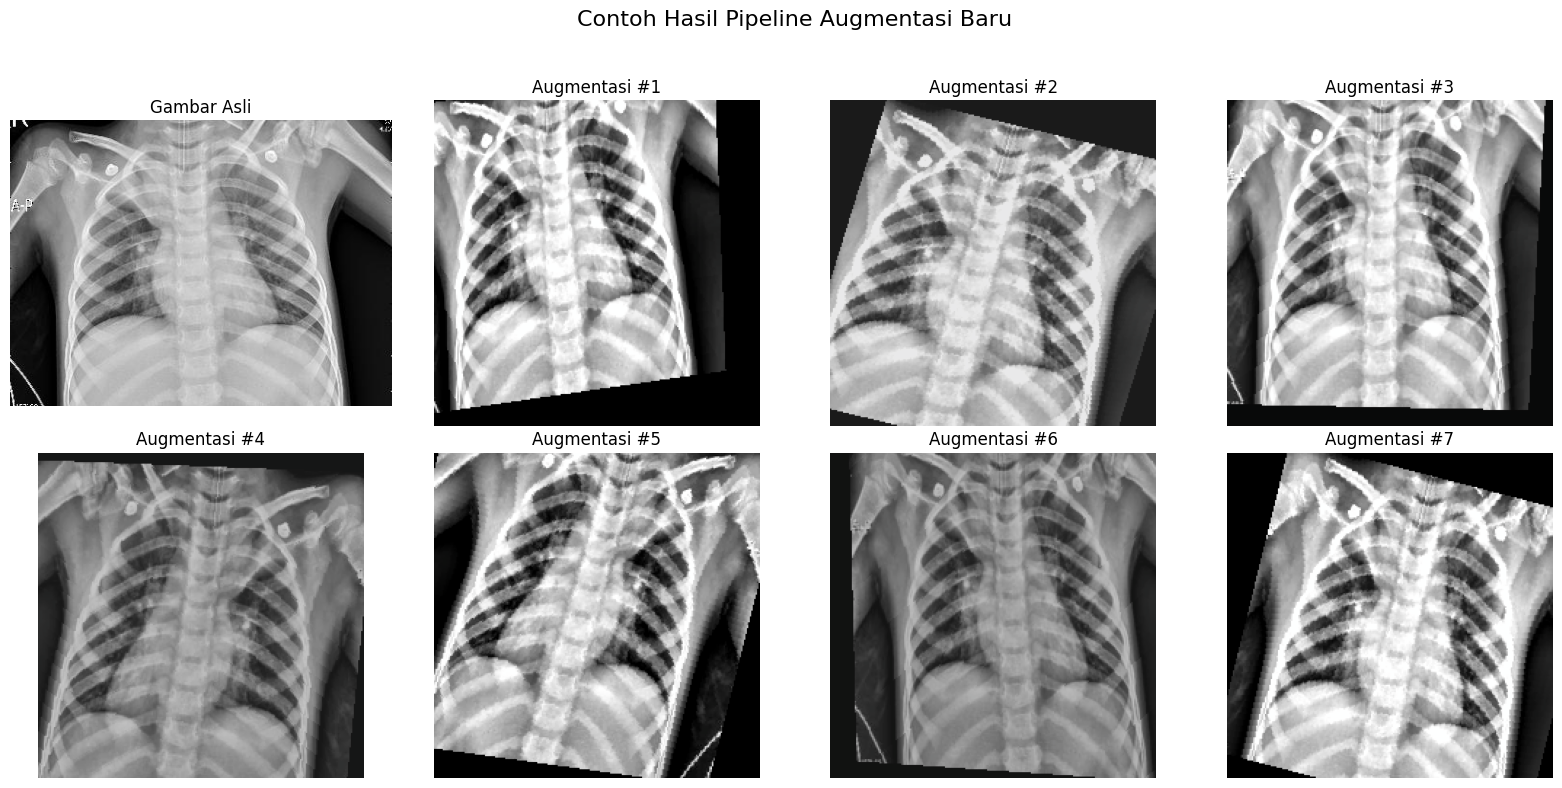

In [56]:
def visualize_augmentations(dataset, num_images=8):
    # Ambil satu gambar acak dari dataset
    idx = random.randint(0, len(dataset) - 1)
    # dataset[idx] akan mengembalikan (gambar, label), kita hanya butuh gambarnya
    # Karena dataset training sudah memiliki transform, kita perlu memuat ulang gambar aslinya
    original_pil_img = Image.open(dataset.samples[idx][0]).convert("RGB")
    
    # Buat plot
    fig, axes = plt.subplots(2, num_images // 2, figsize=(16, 8))
    axes = axes.flatten()
    fig.suptitle("Contoh Hasil Pipeline Augmentasi Baru", fontsize=16)
    
    # Tampilkan gambar asli di posisi pertama
    axes[0].imshow(original_pil_img)
    axes[0].set_title("Gambar Asli")
    axes[0].axis('off')
    
    # Tampilkan hasil augmentasi
    for i in range(1, num_images):
        # Terapkan transformasi baru
        augmented_tensor = new_train_transform(original_pil_img)
        
        # Un-normalize tensor untuk ditampilkan
        un_norm_img = augmented_tensor.numpy().transpose((1, 2, 0))
        mean = np.array(NORM_MEAN)
        std = np.array(NORM_STD)
        un_norm_img = std * un_norm_img + mean
        un_norm_img = np.clip(un_norm_img, 0, 1)
        
        axes[i].imshow(un_norm_img)
        axes[i].set_title(f"Augmentasi #{i}")
        axes[i].axis('off')
        
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Kita perlu instance dataset untuk mengambil sampel
# Asumsikan TRAIN_DIR sudah didefinisikan dari tahap 1
from torchvision import datasets
temp_train_dataset = datasets.ImageFolder(TRAIN_DIR)
visualize_augmentations(temp_train_dataset)

Tahap 3

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import timm
import cv2
import numpy as np
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# ==============================================================================
# 1. DEFINISI ULANG KOMPONEN & PIPELINE (DENGAN PERBAIKAN)
# ==============================================================================

class ApplyCLAHE:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size
    def __call__(self, img):
        img_np = np.array(img)
        gray_img = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        clahe_img = clahe.apply(gray_img)
        img_clahe_3_channel = np.stack([clahe_img]*3, axis=-1)
        return Image.fromarray(img_clahe_3_channel)

# --- Konfigurasi Path dan Transformasi ---
BASE_DIR = '/kaggle/input/srifoton/srifoton-25-machine-learning-competition/'
TRAIN_DIR = os.path.join(BASE_DIR, 'train/train')
VAL_DIR = os.path.join(BASE_DIR, 'val/val')
IMG_SIZE = 224
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]
MODEL_SAVE_PATH_V2 = 'best_model_v2.pth'

# --- KODE YANG DIPERBAIKI ---
new_train_transform = transforms.Compose([
    ApplyCLAHE(),
    # PERBAIKAN: Menambahkan RandomResizedCrop untuk menyeragamkan ukuran gambar
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

val_transform_with_clahe = transforms.Compose([
    ApplyCLAHE(),
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD)
])

# ==============================================================================
# 2. PERSIAPAN DATA LOADER
# ==============================================================================
BATCH_SIZE = 32

train_dataset_v2 = datasets.ImageFolder(TRAIN_DIR, transform=new_train_transform)
val_dataset_v2 = datasets.ImageFolder(VAL_DIR, transform=val_transform_with_clahe)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_v2 = DataLoader(val_dataset_v2, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset_v2.classes
print(f"DataLoaders dengan pipeline baru siap digunakan. Kelas: {class_names}")

# ==============================================================================
# 3. TRAINING LOOP DENGAN PIPELINE BARU
# ==============================================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
model_v2 = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=len(class_names))
model_v2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_v2.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

NUM_EPOCHS = 25
best_f1_score_v2 = 0.0

for epoch in range(NUM_EPOCHS):
    model_v2.train()
    train_loss = 0.0
    for inputs, labels in tqdm(train_loader_v2, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_v2(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    model_v2.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader_v2, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Validating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_v2(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_dataset_v2):.4f} | Val Loss: {val_loss/len(val_dataset_v2):.4f} | Val Macro F1: {val_f1:.4f}")

    if val_f1 > best_f1_score_v2:
        best_f1_score_v2 = val_f1
        torch.save(model_v2.state_dict(), MODEL_SAVE_PATH_V2)
        print(f"✨ Model V2 terbaik disimpan! Macro F1: {best_f1_score_v2:.4f}")
    
    scheduler.step()

print("\nTraining V2 selesai!")

# ==============================================================================
# 4. EVALUASI AKHIR MODEL V2
# ==============================================================================
# (Kode evaluasi tetap sama dan akan berjalan setelah training selesai)
print("\nMemuat model V2 terbaik untuk evaluasi akhir...")
model_v2.load_state_dict(torch.load(MODEL_SAVE_PATH_V2))
model_v2.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in tqdm(val_loader_v2, desc="Evaluasi Akhir"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_v2(inputs)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# --- Tampilkan Classification Report Baru ---
print("\n" + "="*50)
print("     Laporan Klasifikasi Baru (Model V2 - Validation Set)")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

# --- Tampilkan Confusion Matrix Baru ---
print("\n" + "="*50)
print("     Visualisasi Confusion Matrix Baru (Model V2)")
print("="*50)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix Baru - Model V2', fontsize=16)
plt.ylabel('Label Asli (True Label)', fontsize=12)
plt.xlabel('Label Prediksi (Predicted Label)', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

DataLoaders dengan pipeline baru siap digunakan. Kelas: ['Bacterial Pneumonia', 'Corona Virus Disease', 'Normal', 'Tuberculosis', 'Viral Pneumonia']


Epoch 1/25 - Training:   0%|          | 0/190 [00:00<?, ?it/s]

Epoch 1/25 - Validating:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.6050 | Val Loss: 0.4271 | Val Macro F1: 0.8174
✨ Model V2 terbaik disimpan! Macro F1: 0.8174


Epoch 2/25 - Training:   0%|          | 0/190 [00:00<?, ?it/s]

...

Epoch 6/25 - Training:   0%|          | 0/190 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f7cd00c3880>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1601, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.11/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f7cd00c3880>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 6/25 - Validating:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 6 | Train Loss: 0.1923 | Val Loss: 0.3052 | Val Macro F1: 0.8705


Epoch 7/25 - Training:   0%|          | 0/190 [00:00<?, ?it/s]